<div style="background-color: #f8f9fa; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">
  <div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="https://sigmoidal.ai/wp-content/uploads/2024/09/Academia-Sigmoidal-Light.png" alt="Academia Sigmoidal Logo" width="250" height="auto">
    <div style="text-align: right;">
<h1 style="color: #007bff; margin: 0; font-size: 24px;">Pós-Graduação em Visão Computacional</h1>
    </div>
</div>
<hr style="border: none; height: 1px; background-color: #007bff; margin: 20px 0;">
<h3 style="color: #343a40; margin: 0; font-size: 20px;"><strong>VIS101: Fundamentos da Visão Computacional</strong></h3>
<p style="color: #6c757d; margin: 5px 0 0; font-size: 14px;"><strong>Instrutor:</strong> Carlos Melo, MSc.</p>
</div>

<a href="https://colab.research.google.com/github/carlosfab/visao-computacional/blob/main/vis101/chroma-key-video/chroma_key_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chroma key em vídeo

O chroma key consiste em segmentar o fundo de cor uniforme de uma gravação e substituí-lo por outro cenário. É a segmentação por cor com a lógica invertida: a máscara descreve o fundo, e o complemento corresponde ao objeto de interesse.

O notebook também introduz a leitura e a escrita de vídeo no OpenCV.

## Preparação

In [ ]:
# !mkdir -p data
# !wget -q https://raw.githubusercontent.com/carlosfab/visao-computacional/main/vis101/chroma-key-video/data/greenscreen.mp4 -O data/greenscreen.mp4
# !wget -q https://raw.githubusercontent.com/carlosfab/visao-computacional/main/vis101/chroma-key-video/data/fundo-deserto.mp4 -O data/fundo-deserto.mp4

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (10, 5), 'font.size': 12})

## Leitura de vídeo

Um vídeo é uma sequência de quadros. `cv2.VideoCapture` abre o arquivo; `read()` retorna um booleano de sucesso e o quadro corrente (matriz BGR). O booleano torna-se `False` ao fim do arquivo.

In [2]:
cap = cv2.VideoCapture('../videos/greenscreen.mp4')

ok, frame = cap.read()
print('leitura:', ok, '| dimensões do quadro:', frame.shape)

leitura: True | dimensões do quadro: (716, 1284, 3)


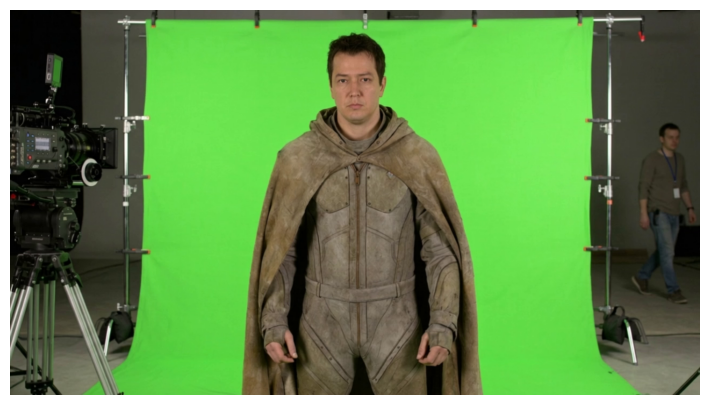

In [3]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

Metadados relevantes: taxa de quadros (FPS) e contagem total. O FPS é requerido na escrita do vídeo de saída.

In [4]:
fps = cap.get(cv2.CAP_PROP_FPS)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print('FPS:', round(fps, 1), '| quadros:', total)

FPS: 24.0 | quadros: 121


Leitura integral: laço sobre `read()` até o retorno `False`, seguido de `release()`.

In [5]:
cap = cv2.VideoCapture('../videos/greenscreen.mp4')
frames = []
while True:
    ok, frame = cap.read()
    if not ok:
        break
    frames.append(frame)
cap.release()
print('quadros carregados:', len(frames))

quadros carregados: 121


## Máscara do fundo

Máscara do verde via `inRange` em HSV, seguida de fechamento morfológico para preencher descontinuidades.

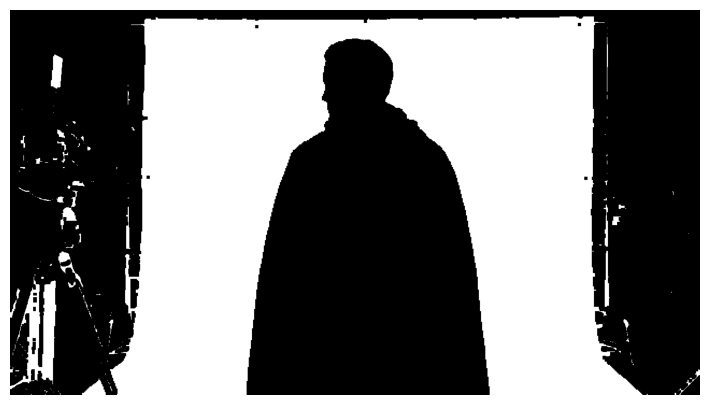

In [6]:
frame = frames[len(frames) // 2]
hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

verde = cv2.inRange(hsv, (35, 70, 50), (90, 255, 255))
verde = cv2.morphologyEx(verde, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))

plt.imshow(verde, cmap='gray')
plt.axis('off')
plt.show()

A inversão da máscara marca tudo o que não é verde, o que inclui o entorno do estúdio visível nas bordas da gravação.

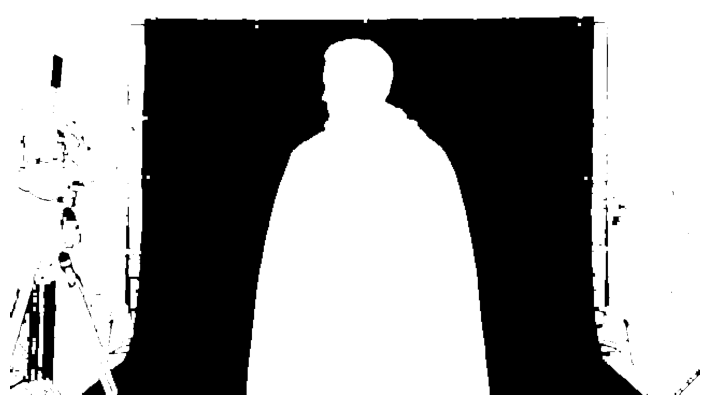

In [7]:
pessoa = cv2.bitwise_not(verde)

plt.imshow(pessoa, cmap='gray')
plt.axis('off')
plt.show()

## Garbage matte

Restrição espacial aplicada antes de qualquer seleção de componente: mantém-se apenas a faixa central do quadro, onde o objeto de interesse se encontra. A ordem é determinante, pois o entorno do estúdio forma um componente conexo que pode exceder a área do objeto.

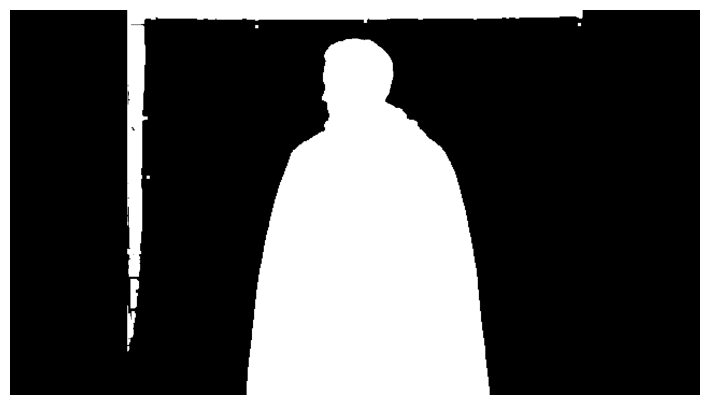

In [8]:
h, w = pessoa.shape
faixa = np.zeros_like(pessoa)
faixa[:, int(0.17 * w):int(0.83 * w)] = 255
pessoa = cv2.bitwise_and(pessoa, faixa)

plt.imshow(pessoa, cmap='gray')
plt.axis('off')
plt.show()

Abertura morfológica para remoção de ruído, seleção do maior contorno e suavização da borda da máscara.

In [9]:
pessoa = cv2.morphologyEx(pessoa, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))

cnts, _ = cv2.findContours(pessoa, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask = np.zeros_like(pessoa)
if cnts:
    cv2.drawContours(mask, [max(cnts, key=cv2.contourArea)], -1, 255, -1)

mask = cv2.GaussianBlur(mask, (7, 7), 0)

## Composição alfa

A máscara normalizada em [0, 1] pondera a média pixel a pixel entre o quadro e o cenário. A supressão de spill limita o canal G à média dos demais canais, atenuando o reflexo verde na borda do objeto.

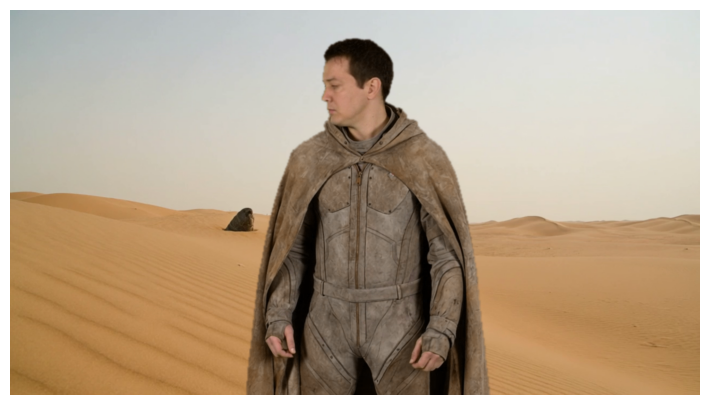

In [10]:
cap = cv2.VideoCapture('../videos/fundo-deserto.mp4')
ok, fundo = cap.read()
cap.release()
fundo = cv2.resize(fundo, (frame.shape[1], frame.shape[0]))

B, G, R = cv2.split(frame.astype(np.int16))
G = np.minimum(G, (B + R) // 2)
frame_ss = cv2.merge([B, G, R]).astype(np.uint8)

alpha = (mask / 255.0)[..., None]
composto = (frame_ss * alpha + fundo * (1 - alpha)).astype(np.uint8)

plt.imshow(cv2.cvtColor(composto, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## Processamento do vídeo completo

A função consolida a sequência de operações na ordem construída acima.

In [11]:
def compor(frame, fundo):
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # máscara do fundo verde
    verde = cv2.inRange(hsv, (35, 70, 50), (90, 255, 255))
    verde = cv2.morphologyEx(verde, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    pessoa = cv2.bitwise_not(verde)

    # garbage matte antes da seleção de componente
    h, w = pessoa.shape
    faixa = np.zeros_like(pessoa)
    faixa[:, int(0.17 * w):int(0.83 * w)] = 255
    pessoa = cv2.bitwise_and(pessoa, faixa)

    # limpeza e maior contorno
    pessoa = cv2.morphologyEx(pessoa, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    cnts, _ = cv2.findContours(pessoa, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(pessoa)
    if cnts:
        cv2.drawContours(mask, [max(cnts, key=cv2.contourArea)], -1, 255, -1)

    # borda suave e supressão de spill
    mask = cv2.GaussianBlur(mask, (7, 7), 0)
    alpha = (mask / 255.0)[..., None]
    B, G, R = cv2.split(frame.astype(np.int16))
    G = np.minimum(G, (B + R) // 2)
    frame = cv2.merge([B, G, R]).astype(np.uint8)

    # composição
    fundo = cv2.resize(fundo, (frame.shape[1], frame.shape[0]))
    return (frame * alpha + fundo * (1 - alpha)).astype(np.uint8)

In [14]:
cap = cv2.VideoCapture('../videos/fundo-deserto.mp4')
fundo_frames = []
while True:
    ok, f = cap.read()
    if not ok:
        break
    fundo_frames.append(f)
cap.release()

n = min(len(frames), len(fundo_frames))
print('quadros a compor:', n)

quadros a compor: 121


## Escrita do vídeo

`cv2.VideoWriter` requer o arquivo de saída, o codec (`VideoWriter_fourcc`), o FPS e o tamanho do quadro na ordem (largura, altura). `release()` finaliza o arquivo.

In [15]:
h, w = frames[0].shape[:2]
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
saida = cv2.VideoWriter('../videos/resultado.mp4', fourcc, fps, (w, h))

for i in range(n):
    saida.write(compor(frames[i], fundo_frames[i]))

saida.release()
print('vídeo salvo em resultado.mp4')

vídeo salvo em resultado.mp4


Verificação em três instantes do resultado.

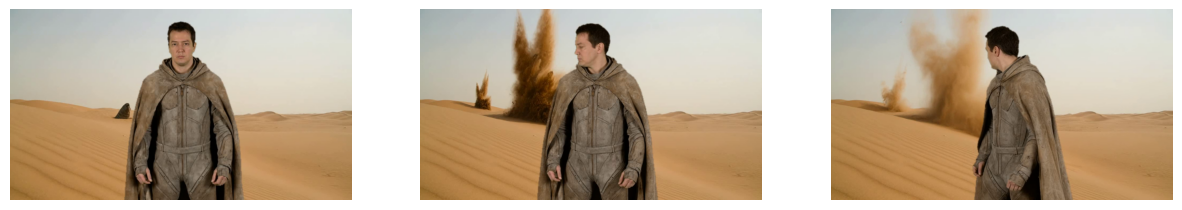

In [17]:
cap = cv2.VideoCapture('../videos/resultado.mp4')
total_out = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, i in zip(axes, [5, total_out // 2, total_out - 5]):
    cap.set(cv2.CAP_PROP_POS_FRAMES, i)
    ok, f = cap.read()
    ax.imshow(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
    ax.axis('off')
cap.release()
plt.show()

No Colab, o arquivo pode ser baixado diretamente.

In [18]:
# from google.colab import files
# files.download('resultado.mp4')